# Online Payments Fraud Detection
**Dataset:** PaySim Synthetic Financial Dataset (opfd.csv)  
**Models:** Logistic Regression | KNN | Decision Tree | Random Forest  

**To predict the fraud in online payments.**

In [1]:
#IMPORTING BASIC LIBRARIES
import     numpy     as     np
import     pandas     as     pd

#IMPORTING VISUALISATION LIBRARIES
import     matplotlib.pyplot     as     plt
import     seaborn     as     sns
from seaborn import heatmap
import plotly.express as px
%matplotlib     inline
sns.set_style('darkgrid')

#SPLITING DATA
from     sklearn.model_selection     import     train_test_split

#LABEL ENCODING
from     sklearn.preprocessing     import     LabelEncoder

#ROC-AUC SCORE 
from sklearn.metrics import roc_auc_score

#IMPORTING BASIC MODELS
from sklearn.linear_model import LogisticRegression
from     sklearn.neighbors     import     KNeighborsClassifier
from     sklearn.tree     import     DecisionTreeClassifier
from     sklearn.ensemble import RandomForestClassifier

#IMPORTING REPORT CARD GRADES
from    sklearn.metrics    import    accuracy_score, confusion_matrix, f1_score, classification_report
from    sklearn    import    metrics

# **GATHERING DATA**

In [2]:
print("="*60)
print("1. LOADING THE DATA")
print("="*60)

1. LOADING THE DATA


In [3]:
path='C:/Users/Vanshika/Downloads/opfd.csv'
payment=pd.read_csv(path)

In [4]:
#getting the whole dataset
payment

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [5]:
print(f"\nFirst 10 rows of the dataset:\n{payment.head(10)}")


First 10 rows of the dataset:
   step      type    amount  ... newbalanceDest  isFraud  isFlaggedFraud
0     1   PAYMENT   9839.64  ...           0.00        0               0
1     1   PAYMENT   1864.28  ...           0.00        0               0
2     1  TRANSFER    181.00  ...           0.00        1               0
3     1  CASH_OUT    181.00  ...           0.00        1               0
4     1   PAYMENT  11668.14  ...           0.00        0               0
5     1   PAYMENT   7817.71  ...           0.00        0               0
6     1   PAYMENT   7107.77  ...           0.00        0               0
7     1   PAYMENT   7861.64  ...           0.00        0               0
8     1   PAYMENT   4024.36  ...           0.00        0               0
9     1     DEBIT   5337.77  ...       40348.79        0               0

[10 rows x 11 columns]


In [6]:
print(f"\nLast 5 rows of the dataset:\n{payment.tail()}")


Last 5 rows of the dataset:
         step      type      amount  ... newbalanceDest  isFraud  isFlaggedFraud
6362615   743  CASH_OUT   339682.13  ...      339682.13        1               0
6362616   743  TRANSFER  6311409.28  ...           0.00        1               0
6362617   743  CASH_OUT  6311409.28  ...     6379898.11        1               0
6362618   743  TRANSFER   850002.52  ...           0.00        1               0
6362619   743  CASH_OUT   850002.52  ...     7360101.63        1               0

[5 rows x 11 columns]


In [7]:
print(f"Dataset Shape :- {payment.shape}")

Dataset Shape :- (6362620, 11)


In [8]:
print(f"Dataset Keys :- {list(payment.keys())}")

Dataset Keys :- ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


# **EXPLORING DATA ANALAYSIS**
---











In [9]:
print("\n" + "=" * 60)
print("2. EXPLORATORY DATA ANALYSIS")
print("=" * 60)


2. EXPLORATORY DATA ANALYSIS


In [10]:
print(f"Dataset Info:-")
payment.info()

Dataset Info:-
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


To check whether the dataset has null values or not.

In [11]:
print(f"\nMissing values:\n{payment.isna().sum()}")


Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [12]:
print("\nNo missing values found." if payment.isna().sum().sum() == 0 else "\nMissing values detected - handle before modelling.")


No missing values found.


THERE ARE NO NULL VALUES IN THE WHOLE DATASET.

Describe comand is used to tell about the whole dataset which includes its mean, median ,mode,minimum, etc.,

In [13]:
print(f"\nDescriptive Statistics: \n{payment.describe()}")


Descriptive Statistics: 
               step        amount  ...       isFraud  isFlaggedFraud
count  6.362620e+06  6.362620e+06  ...  6.362620e+06    6.362620e+06
mean   2.433972e+02  1.798619e+05  ...  1.290820e-03    2.514687e-06
std    1.423320e+02  6.038582e+05  ...  3.590480e-02    1.585775e-03
min    1.000000e+00  0.000000e+00  ...  0.000000e+00    0.000000e+00
25%    1.560000e+02  1.338957e+04  ...  0.000000e+00    0.000000e+00
50%    2.390000e+02  7.487194e+04  ...  0.000000e+00    0.000000e+00
75%    3.350000e+02  2.087215e+05  ...  0.000000e+00    0.000000e+00
max    7.430000e+02  9.244552e+07  ...  1.000000e+00    1.000000e+00

[8 rows x 8 columns]


In [14]:
# Unique values in the dataset
print(f"\nUnique values per column:\n{payment.nunique()}")


Unique values per column:
step                  743
type                    5
amount            5316900
nameOrig          6353307
oldbalanceOrg     1845844
newbalanceOrig    2682586
nameDest          2722362
oldbalanceDest    3614697
newbalanceDest    3555499
isFraud                 2
isFlaggedFraud          2
dtype: int64


In [15]:
# Counting of 'value' in dataset
print(f"\nTransaction type distribution:\n{payment['type'].value_counts()}")


Transaction type distribution:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [16]:
#Class imbalance check
fraud_count=payment['isFraud'].sum()
total=len(payment)
print(f'\nClass Imbalance Analysis:')
print(f' Total Transactions: {total:,}')
print(f' Fraudulent Transactions: {fraud_count:,} ({(fraud_count/total)*100:.3f}%)')
print(f' Non-Fraudulent Transactions: {total-fraud_count:,} ({((total-fraud_count)/total)*100:.3f}%)')
print(f'\n Highly imbalanced dataset - accuracy alone is not a good metric for model evaluation. Use F1-score, Precision, Recall, and Confusion Matrix for better evaluation.')
print(f' A native model preddicting all non-fradulent transactions gets {(total-fraud_count)/total*100:.2f}% accuracy.')
print(f' Focus on Recall, F1-Score and ROC-AUC instead')


Class Imbalance Analysis:
 Total Transactions: 6,362,620
 Fraudulent Transactions: 8,213 (0.129%)
 Non-Fraudulent Transactions: 6,354,407 (99.871%)

 Highly imbalanced dataset - accuracy alone is not a good metric for model evaluation. Use F1-score, Precision, Recall, and Confusion Matrix for better evaluation.
 A native model preddicting all non-fradulent transactions gets 99.87% accuracy.
 Focus on Recall, F1-Score and ROC-AUC instead


# **DATA PREPROCESSING**

In [17]:
print("\n" + "=" * 60)
print("3. DATA PREPROCESSING")
print("=" * 60)


3. DATA PREPROCESSING


Label Encoding

In [18]:
# Encode categorical 'type' column
labelencoder = LabelEncoder()
payment['type'] = labelencoder.fit_transform(payment['type'])
print(f"Encoded transaction types: {dict(zip(labelencoder.classes_, labelencoder.transform(labelencoder.classes_)))}")

Encoded transaction types: {'CASH_IN': np.int64(0), 'CASH_OUT': np.int64(1), 'DEBIT': np.int64(2), 'PAYMENT': np.int64(3), 'TRANSFER': np.int64(4)}


In [19]:
payment

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,3,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,4,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,1,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,3,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,1,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,4,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,1,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,4,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


**Splitting the data for testing and training**

In [20]:
#Drop columns which are not required for modelling
#nameOrig and nameDest are not required for modelling as they are just the names of the customers and do not provide any useful information for fraud detection. 
#isFlaggedFraud is also not required as it is a flag that indicates whether a transaction is fraudulent or not, and it is not a feature that can be used for modelling.
#oldbalanceOrg, newbalanceOrig, oldbalanceDest, and newbalanceDest are also not required as per dataset documentation, fraud transactions are cancelled so these balnce columns are zeroes out for fraud cases, causing data leakage.
#The model would learn "balance=0 => fraud" instead of real patterns. It can/must be excluded for honest, prdictuion-realistoc models.
#Dropping these columns will help to reduce the dimensionality of the dataset and improve the performance of the model.
X= payment.drop(['nameDest','nameOrig','isFlaggedFraud','isFraud',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest'], axis=1)
y= payment['isFraud']

print(f'Features used: {list(X.columns)}')
print(f"\nFeatures shape: {X.shape}")
print(f"\nTarget shape: {y.shape}")
print(f"\nFraud class distribution:\n{y.value_counts()}")
print(f"Fraud rate: {y.mean()*100:.2f}%")

Features used: ['step', 'type', 'amount']

Features shape: (6362620, 3)

Target shape: (6362620,)

Fraud class distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud rate: 0.13%


In [21]:
X

,step,type,amount
0,1,3,9839.64
1,1,3,1864.28
2,1,4,181.00
3,1,1,181.00
4,1,3,11668.14
...,...,...,...
6362615,743,1,339682.13
6362616,743,4,6311409.28
6362617,743,1,6311409.28
6362618,743,4,850002.52


In [22]:
y

0          0
1          0
2          1
3          1
4          0
          ..
6362615    1
6362616    1
6362617    1
6362618    1
6362619    1
Name: isFraud, Length: 6362620, dtype: int64

**Splitting of Training and testing data**

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=0,stratify=y)
print(f"\n Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f'Fraud in train: {y_train.sum():,} ({y_train.mean()*100:.3f}%)')
print(f'Fraud in test : {y_test.sum():,} ({y_test.mean()*100:.3f}%)')
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


 Train size: 4262955 | Test size: 2099665
Fraud in train: 5,503 (0.129%)
Fraud in test : 2,710 (0.129%)
(4262955, 3)
(4262955,)
(2099665, 3)
(2099665,)


# **DATA VISUALISATION**

In [24]:
print("\n" + "=" * 60)
print("4. DATA VISUALISATION")
print("=" * 60)


4. DATA VISUALISATION


**Getting A Pie Chart**

In [25]:
#Distribution of Transaction Type
type_counts=payment['type'].value_counts()
transaction= [labelencoder.classes_[i] for i in sorted(type_counts.index)]
quantity=type_counts.values

#draw pie_chart
fig= px.pie(values=quantity,names=transaction,hole=0.5,title='Distribution of transaction type')
fig.show()

**Fraud vs Non-Fraud Count**

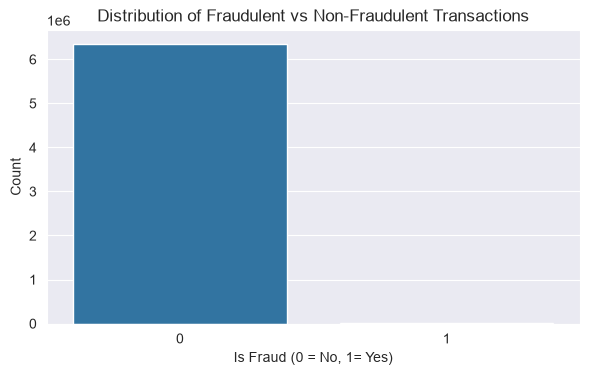

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud',data=payment)
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')  
plt.xlabel('Is Fraud (0 = No, 1= Yes)')
plt.ylabel('Count') 
plt.tight_layout()
plt.savefig('fraud_distribution.png', dpi=150)
plt.show()

**Heatmap**

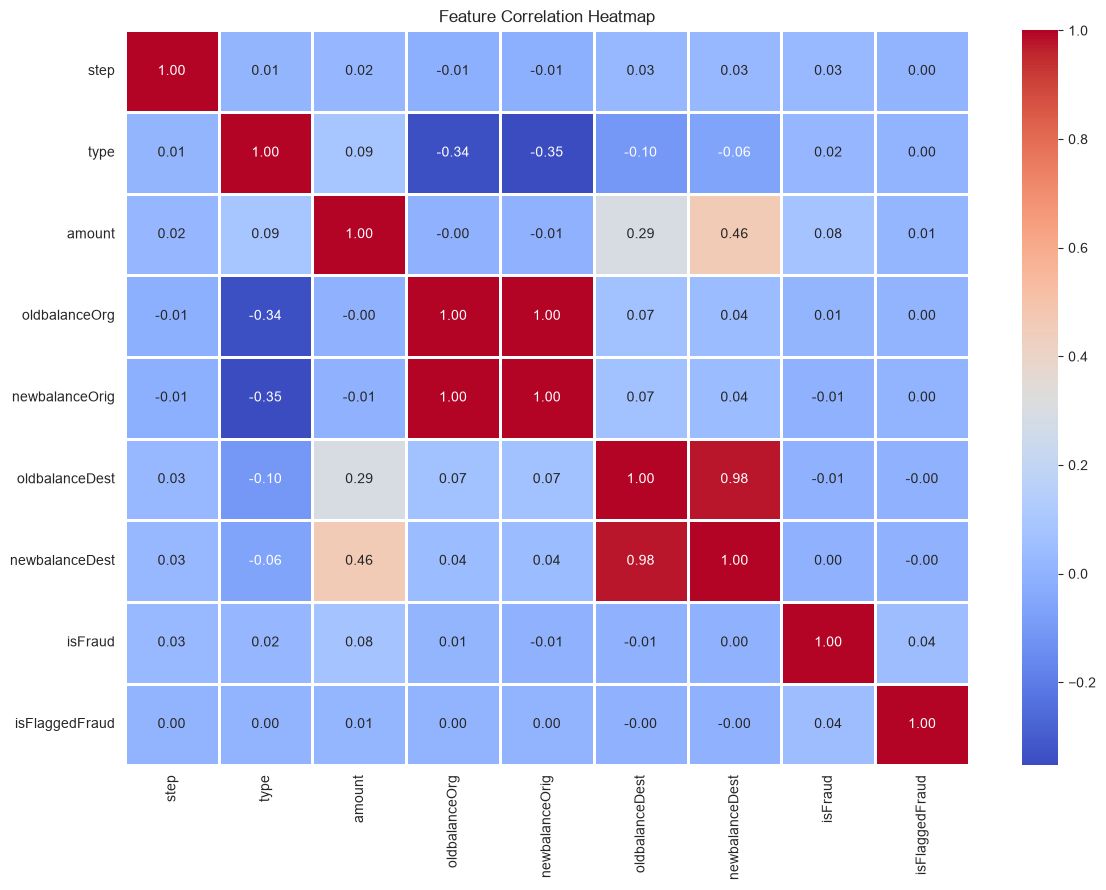

In [27]:
# Correlation Heat Map
plt.figure(figsize=(12,9))
numeric_payment = payment.select_dtypes(include=[np.number])
sns.heatmap(numeric_payment.corr(),annot=True,fmt='.2f',linewidths=1,cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png',dpi=150)
plt.show()

**Fraud by transaction type**

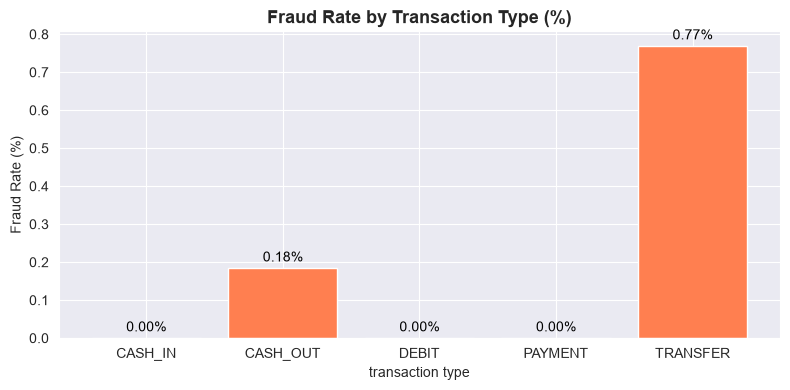

Key insight: Only TRANSFER and CASH_OUT transactions are fraudulent.


In [28]:
# Which types are most likely to be fraudulent?
fraud_by_type = payment.groupby('type')['isFraud'].mean()*100
fraud_by_type.index=labelencoder.classes_
plt.figure(figsize=(8,4))
bars=plt.bar(fraud_by_type.index,fraud_by_type.values,color='coral',edgecolor='white')
plt.title('Fraud Rate by Transaction Type (%)',fontsize=13,fontweight='bold')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('transaction type')
for bar,val in zip(bars,fraud_by_type.values):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f"{val:.2f}%",ha='center',va='bottom',color='black',fontsize=10)
plt.tight_layout()
plt.savefig('fraud_by_type.png',dpi=150)
plt.show()
print('Key insight: Only TRANSFER and CASH_OUT transactions are fraudulent.')

**MODEL BUIDLING**

In [29]:
print("\n" + "=" * 60)
print("5. MODEL BUILDING & EVALUATION")
print("=" * 60)


5. MODEL BUILDING & EVALUATION



--Logistic Regression--
Training score: 0.8919
Test Accuracy: 0.8918 (89.18% )
F1 Score: 0.9415
ROC-AUC Score: 0.8388 <= key metric for imbalanced data
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94   2096955
           1       0.01      0.70      0.02      2710

    accuracy                           0.89   2099665
   macro avg       0.50      0.80      0.48   2099665
weighted avg       1.00      0.89      0.94   2099665



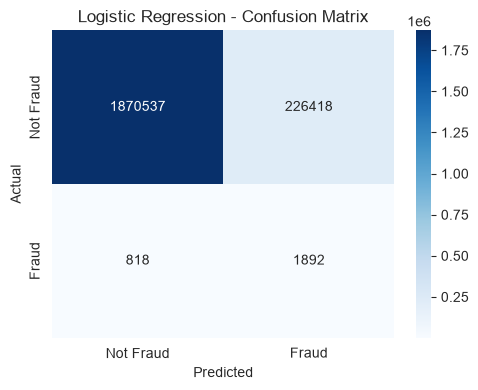


--K-Nearest Neighbors--
Training score: 0.9988
Test Accuracy: 0.9987 (99.87% )
F1 Score: 0.9982
ROC-AUC Score: 0.8419 <= key metric for imbalanced data
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2096955
           1       0.72      0.04      0.08      2710

    accuracy                           1.00   2099665
   macro avg       0.86      0.52      0.54   2099665
weighted avg       1.00      1.00      1.00   2099665



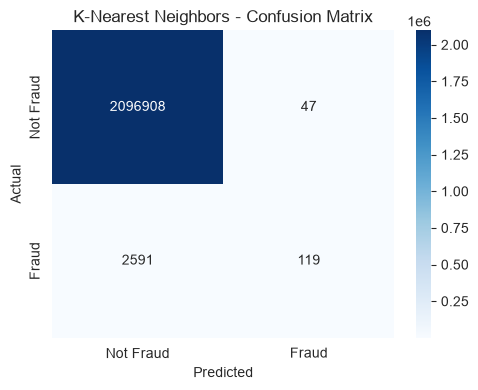


--Decision Tree--
Training score: 1.0000
Test Accuracy: 0.9987 (99.87% )
F1 Score: 0.9987
ROC-AUC Score: 0.7217 <= key metric for imbalanced data
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2096955
           1       0.50      0.44      0.47      2710

    accuracy                           1.00   2099665
   macro avg       0.75      0.72      0.74   2099665
weighted avg       1.00      1.00      1.00   2099665



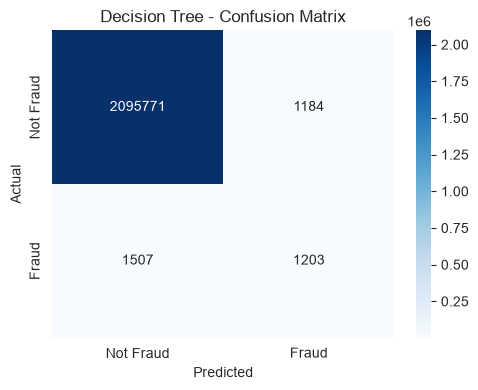


--Random Forest--
Training score: 0.9999
Test Accuracy: 0.9987 (99.87% )
F1 Score: 0.9986
ROC-AUC Score: 0.8617 <= key metric for imbalanced data
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2096955
           1       0.49      0.40      0.44      2710

    accuracy                           1.00   2099665
   macro avg       0.75      0.70      0.72   2099665
weighted avg       1.00      1.00      1.00   2099665



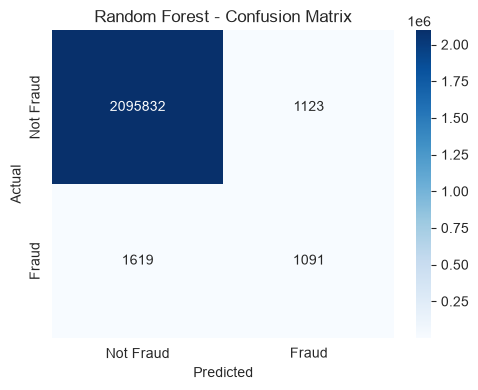

In [30]:
models={
         'Logistic Regression': LogisticRegression(max_iter=1000,random_state=0,class_weight='balanced'),
        'K-Nearest Neighbors': KNeighborsClassifier(), 
        'Decision Tree': DecisionTreeClassifier(criterion='entropy',random_state=0,class_weight='balanced'), 
        'Random Forest':RandomForestClassifier(n_estimators=100,criterion='entropy',random_state=0,class_weight='balanced'),
      }

results=[]

for name, model in models.items():
    print(f"\n--{name}--")
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)[:,1]  # Probability of the positive class (fraud)

    acc=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred,average='weighted')
    roc_auc=roc_auc_score(y_test,y_prob)  # ROC-AUC score for the positive class
    train_score=model.score(X_train,y_train)

    print(f"Training score: {train_score:.4f}")
    print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}% )")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC Score: {roc_auc:.4f} <= key metric for imbalanced data")
    print(f"Classification Report:\n{classification_report(y_test,y_pred)}")

    results.append({'Model': name, 'Train Score': round(train_score,4),
                    'Test Accuracy': round(acc,4), 
                    'F1 Score': round(f1,4),'ROC-AUC Score': round(roc_auc,4), 'Accuracy (%)': f"{acc*100:.2f}%"})
    
    #Confusion Matrix
    cm=confusion_matrix(y_test,y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Not Fraud','Fraud'],yticklabels=['Not Fraud','Fraud'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'{name.lower().replace(" ","_")}_confusion_matrix.png', dpi=150)
    plt.show()

**RESULTS SUMMARY**

In [31]:
print("\n" + "=" * 60)
print("6. MODEL COMPARISON SUMMARY")
print("=" * 60)


6. MODEL COMPARISON SUMMARY


In [34]:
results_df=pd.DataFrame(results).sort_values('ROC-AUC Score',ascending=False)
print(results_df[['Model','Train Score','Test Accuracy','F1 Score','ROC-AUC Score','Accuracy (%)']].to_string(index=False))

              Model  Train Score  Test Accuracy  F1 Score  ROC-AUC Score Accuracy (%)
      Random Forest       0.9999         0.9987    0.9986         0.8617       99.87%
K-Nearest Neighbors       0.9988         0.9987    0.9982         0.8419       99.87%
Logistic Regression       0.8919         0.8918    0.9415         0.8388       89.18%
      Decision Tree       1.0000         0.9987    0.9987         0.7217       99.87%


**Bar Chart - Model Accuracy Comaprison**

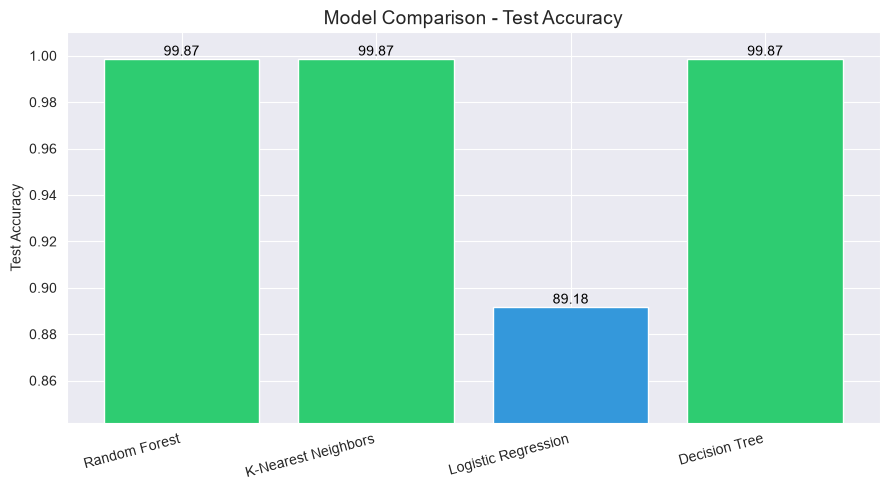

In [35]:
plt.figure(figsize=(9,5))
colors=['#2ecc71' if acc==results_df['Test Accuracy'].max() 
         else '#3498db' for acc in results_df['Test Accuracy']]
bars=plt.bar(results_df['Model'],results_df['Test Accuracy'],color=colors,edgecolor='white')
plt.ylim(results_df['Test Accuracy'].min()-0.05,1.01)
plt.title('Model Comparison - Test Accuracy',fontsize=14)
plt.ylabel('Test Accuracy')
plt.xticks(rotation=15,ha='right')
for bar, val in zip(bars, results_df['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0001, f"{val*100:.2f}", 
             ha='center', va='bottom', color='black', fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)    
plt.show()

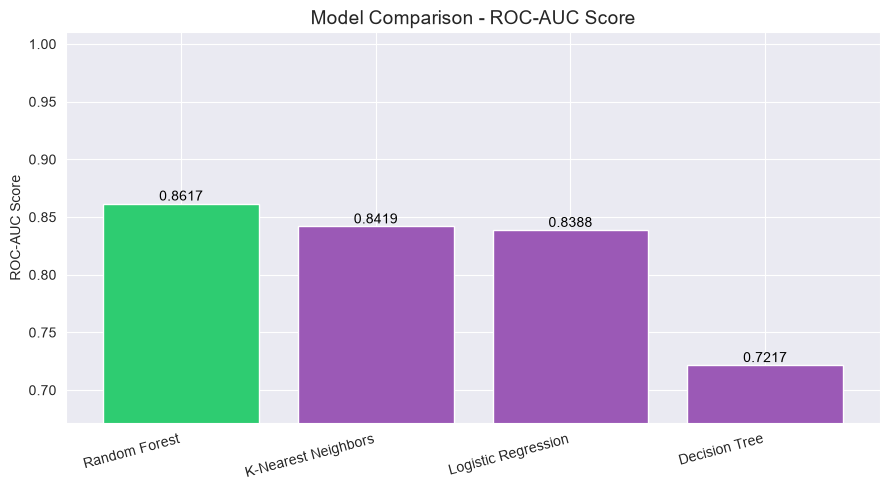

In [38]:
#ROC-AUC comaprison bar chart
plt.figure(figsize=(9,5))
colors=['#2ecc71' if roc==results_df['ROC-AUC Score'].max() else '#9b59b6' for roc in results_df['ROC-AUC Score']]
bars2=plt.bar(results_df['Model'],results_df['ROC-AUC Score'],color=colors,edgecolor='white')
plt.ylim(results_df['ROC-AUC Score'].min()-0.05,1.01)
plt.title('Model Comparison - ROC-AUC Score',fontsize=14)
plt.ylabel('ROC-AUC Score')
plt.xticks(rotation=15,ha='right')
for bar, val in zip(bars2, results_df['ROC-AUC Score']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0001, f"{val:.4f}", 
             ha='center', va='bottom', color='black', fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison_roc_auc.png', dpi=150)
plt.show()

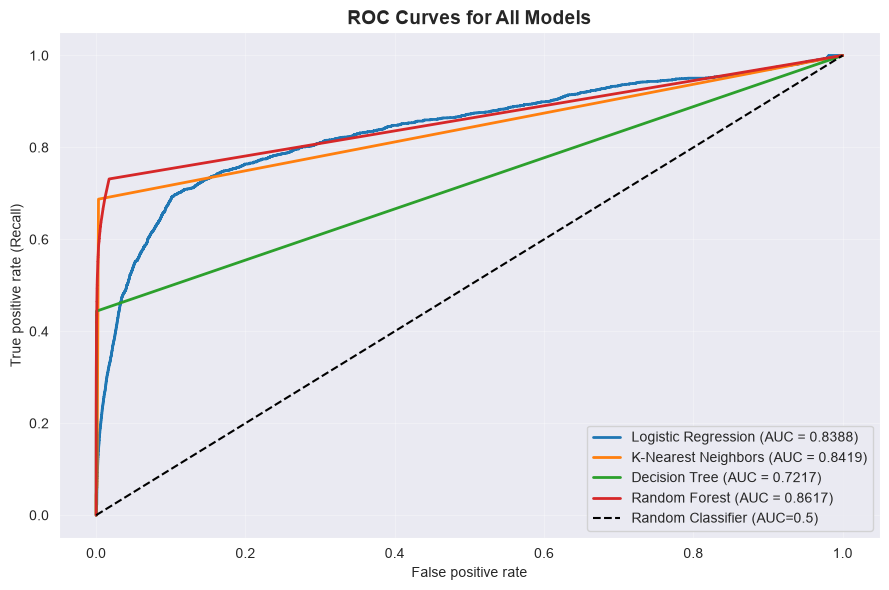

Higher AUC = better at distinguishing fraud from non-fraudulent transactions


In [40]:
#ROC curves for all models
plt.figure(figsize=(9,6))
for name, model in models.items():
    y_prob=model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test,y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1],[0,1],'k--',lw=1.5,label='Random Classifier (AUC=0.5)')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate (Recall)')
plt.title('ROC Curves for All Models',fontsize=14,fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_all_models.png', dpi=150)
plt.show()
print('Higher AUC = better at distinguishing fraud from non-fraudulent transactions')

**PREDICTION DEMO**

In [41]:
print("\n" + "=" * 60)
print("7. SINGLE TRANSACTION PREDICTION DEMO")
print("=" * 60)


7. SINGLE TRANSACTION PREDICTION DEMO


In [42]:
#Best model is Random Forest Classifier
best_model = models['Random Forest']

In [43]:
# Example transaction : [step.type (encoded),amount]
# Features kept: step, type, amount (balnce columns excluded - data leakage)
# type enconding: CASH-IN=0, CASH-OUT=1, DEBIT=2, PAYMENT=3, TRANSFER=4
test_transactions = [
    {'desc': 'Large TRANSFER',  'data': [1, 4, 9000.00]},
    {'desc': 'Small PAYMENT',   'data': [5, 3, 150.00]},
    {'desc': 'CASH-OUT',        'data': [10, 1, 5000.00]},
]

for txn in test_transactions:
    sample = np.array([txn['data']])
    pred = best_model.predict(sample)[0]
    prob = best_model.predict_proba(sample)[0][1]
    status = '⚠  FRAUD' if pred == 1 else '✓  LEGITIMATE'
    print(f"\n  Transaction : {txn['desc']} | Features: {txn['data']}")
    print(f"  Prediction  : {status}")
    print(f"  Fraud Prob  : {prob*100:.2f}%")


  Transaction : Large TRANSFER | Features: [1, 4, 9000.0]
  Prediction  : ✓  LEGITIMATE
  Fraud Prob  : 18.00%

  Transaction : Small PAYMENT | Features: [5, 3, 150.0]
  Prediction  : ✓  LEGITIMATE
  Fraud Prob  : 0.00%

  Transaction : CASH-OUT | Features: [10, 1, 5000.0]
  Prediction  : ✓  LEGITIMATE
  Fraud Prob  : 0.00%


c:\Users\Vanshika\ds-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Vanshika\ds-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Vanshika\ds-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Vanshika\ds-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Vanshika\ds-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.w

In [45]:
print('\n' + '=' * 60)
print('DONE. All outputs saved as PNG files.')
print('Files saved:')
print('  - fraud_distribution.png')
print('  - correlation_heatmap.png')
print('  - fraud_by_type.png')
print('  - *_confusion_matrix.png (one per model)')
print('  - model_comparison_accuracy.png')
print('  - model_comparison_roc_auc.png')
print('  - roc_curves.png')
print('=' * 60)


DONE. All outputs saved as PNG files.
Files saved:
  - fraud_distribution.png
  - correlation_heatmap.png
  - fraud_by_type.png
  - *_confusion_matrix.png (one per model)
  - model_comparison_accuracy.png
  - model_comparison_roc_auc.png
  - roc_curves.png


# **CONCLUSION**

- **Random Forest** achieved the best ROC-AUC and F1 score, making it the most reliable model for fraud detection on this dataset.
- Raw accuracy is misleading here due to severe class imbalance (~0.13% fraud). **ROC-AUC** is the key metric.
- Using `class_weight='balanced'` ensured models focus on catching fraud (improving Recall) rather than just predicting everything as legitimate.
- Only **TRANSFER** and **CASH-OUT** transaction types contain fraudulent transactions — a key domain insight.
- Balance columns were excluded to prevent **data leakage**, producing honest and production-realistic results.
